In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt  
from scipy.optimize import differential_evolution, Bounds
from scipy.stats import spearmanr
import json 

np.random.seed(123452)

### Data

In [2]:
data = pd.read_csv('Data/data2024.csv')
data

,page_name,num_posts,Trump_positive,Trump_negative,Trump_neutral,Kamala_positive,Kamala_negative,Kamala_neutral,Vance_positive,Vance_negative,...,Walz_negative,Walz_neutral,media_type,media_bias,bias_value,factual_reporting,factual_value,comment,country,sentiment_bias
0,ConservativeNewsDly,3020,33,154,399,20,167,152,0,2,...,20,8,website,extreme right,NaN,mixed,NaN,NaN,USA,0.043750
1,NEWSMAX,2860,114,398,440,36,379,202,8,7,...,67,24,TV station,right,7.8,low,7.6,NaN,USA,0.072557
2,WashingtonExaminer,2439,26,228,247,47,234,179,1,10,...,59,17,magazine,right-center,3.8,mostly factual,2.2,NaN,USA,0.025496
3,NewsNationNow,1877,8,177,342,47,40,240,3,12,...,7,23,TV station,least biased,1.2,high,1.1,NaN,USA,-0.196371
4,Breitbart,1552,106,198,112,8,455,32,6,9,...,33,2,website,right,8.1,mixed,6.4,NaN,USA,0.396285
5,TheHill,1358,5,167,41,65,50,87,7,35,...,13,34,newspaper,least biased,0.4,mostly factual,2.2,NaN,USA,-0.381308
6,nytimes,1194,4,314,98,78,31,154,0,9,...,3,18,newspaper,left-center,-4.1,high,1.4,NaN,USA,-0.515110
7,ABCNews,1007,2,118,75,77,34,178,2,6,...,2,24,TV station,left-center,-3.3,high,1.1,NaN,USA,-0.320826
8,FoxNews,966,18,73,43,22,188,74,6,17,...,62,10,TV station/website,right,6.7,mixed,6.1,NaN,USA,0.293006
9,NBCNews,932,4,235,99,39,33,103,0,20,...,4,13,TV station,left-center,-3.6,high,1.0,NaN,USA,-0.455806


In [3]:
data["num_posts"].sum()

38151

Data preparation:

In [4]:
n_media_outlets = data.shape[0]
subjects = ['Trump', 'Kamala', 'Vance', 'Walz']
n_subjects = len(subjects)

In [5]:
data = data.head(n = n_media_outlets).copy()
media_outlets = data['page_name'].to_list()
media_bias_label = data['media_bias'].to_list()
media_bias_value = data['bias_value'].to_list()

Data matrix:

In [6]:
mentions_matrix = np.zeros(shape = [n_media_outlets, n_subjects, 3])
for i in range(n_media_outlets):
    for j in range(n_subjects):
        mentions_matrix[i][j] = np.array(data.iloc[i][[f'{subjects[j]}_negative', f'{subjects[j]}_neutral', f'{subjects[j]}_positive']].to_list())

In [7]:
mentions_matrix.sum()

21683.0

In [8]:
def generate_mentions_matrix_reduced(mentions_matrix, target_fraction):
    
    mentions_matrix_reduced = mentions_matrix.copy()
    
    total_initial = mentions_matrix_reduced.sum()
    target_total = int(target_fraction * total_initial)
    
    current_total = total_initial
    
    while current_total >= target_total:
        i = np.random.randint(0, mentions_matrix_reduced.shape[0])
        j = np.random.randint(0, mentions_matrix_reduced.shape[1])
        k = np.random.randint(0, mentions_matrix_reduced.shape[2])
        
        if mentions_matrix_reduced[i, j, k] > 0:
            mentions_matrix_reduced[i, j, k] -= 1
            current_total -= 1
    
    return mentions_matrix_reduced

In [9]:
def log_likelihood(x, mentions_matrix):

    """ Function to maximize """

    n_rows = mentions_matrix.shape[0]
    n_cols = mentions_matrix.shape[1]

    z, a, b = x[:n_rows], x[n_rows:(n_rows + n_cols)], x[(n_rows + n_cols):]
    
    logl = 0.00
    for i in range(n_rows):
        for j in range(n_cols):
            z_ij = z[i] * a[j] + b[j]
            N_ij = np.sum(mentions_matrix[i][j])
            logl += (mentions_matrix[i][j][2] - mentions_matrix[i][j][0]) * z_ij - N_ij * (np.log(np.exp(z_ij) + 1 + np.exp(-z_ij)))        
    
    for i in range(n_rows):
        logl -= 0.5*(z[i]**2)
        
    for j in range(n_cols):
        logl -= 0.5 *(a[j]**2 + b[j]**2)
    
    return logl

# Auxiliar function to minimize 
negative_log_likelihood = lambda x, mentions_matrix: -log_likelihood(x, mentions_matrix)

### Iteration over sample of data

In [10]:
data2save = []

for target_fraction in [1.00, 0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10]:

    mentions_matrix_reduced = generate_mentions_matrix_reduced(mentions_matrix, target_fraction)
    
    lb = [-5] * (n_media_outlets + 2 * n_subjects)
    ub = [5] * (n_media_outlets + 2 * n_subjects)
    bounds = Bounds(lb, ub)
    
    solution = differential_evolution(negative_log_likelihood, args=(mentions_matrix_reduced,), bounds=bounds, maxiter=200, popsize=20, disp = True, tol = 10e-4)
    
    z_predicted, a_predicted, b_predicted = solution.x[:n_media_outlets], solution.x[n_media_outlets:(n_media_outlets + n_subjects)], solution.x[(n_media_outlets + n_subjects):]

    data2save.append({'target_fraction': target_fraction, 'z': z_predicted})

differential_evolution step 1: f(x)= 31696
differential_evolution step 2: f(x)= 31018.3
differential_evolution step 3: f(x)= 27335.9
differential_evolution step 4: f(x)= 26699.4
differential_evolution step 5: f(x)= 26563.6
differential_evolution step 6: f(x)= 26356.3
differential_evolution step 7: f(x)= 26206.5
differential_evolution step 8: f(x)= 23967.4
differential_evolution step 9: f(x)= 22301.5
differential_evolution step 10: f(x)= 22301.5
differential_evolution step 11: f(x)= 21216.9
differential_evolution step 12: f(x)= 21216.9
differential_evolution step 13: f(x)= 21216.9
differential_evolution step 14: f(x)= 21216.9
differential_evolution step 15: f(x)= 21216.9
differential_evolution step 16: f(x)= 21174.5
differential_evolution step 17: f(x)= 21174.5
differential_evolution step 18: f(x)= 20548.8
differential_evolution step 19: f(x)= 20548.8
differential_evolution step 20: f(x)= 20548.8
differential_evolution step 21: f(x)= 20548.8
differential_evolution step 22: f(x)= 20410.3

differential_evolution step 71: f(x)= 16036.2
differential_evolution step 72: f(x)= 16036.2
differential_evolution step 73: f(x)= 16036.2
differential_evolution step 74: f(x)= 16036.2
differential_evolution step 75: f(x)= 16036.2
differential_evolution step 76: f(x)= 16025.2
differential_evolution step 77: f(x)= 15984.9
differential_evolution step 78: f(x)= 15984.9
differential_evolution step 79: f(x)= 15984.9
differential_evolution step 80: f(x)= 15984.9
differential_evolution step 81: f(x)= 15966
differential_evolution step 82: f(x)= 15966
differential_evolution step 83: f(x)= 15966
differential_evolution step 84: f(x)= 15948.9
differential_evolution step 85: f(x)= 15948.9
differential_evolution step 86: f(x)= 15948.9
differential_evolution step 87: f(x)= 15948.9
differential_evolution step 88: f(x)= 15944.8
differential_evolution step 89: f(x)= 15944.8
differential_evolution step 90: f(x)= 15937.7
differential_evolution step 91: f(x)= 15936.2
differential_evolution step 92: f(x)= 15

differential_evolution step 14: f(x)= 12645.4
differential_evolution step 15: f(x)= 12438.7
differential_evolution step 16: f(x)= 12438.7
differential_evolution step 17: f(x)= 12438.7
differential_evolution step 18: f(x)= 12438.7
differential_evolution step 19: f(x)= 12415.8
differential_evolution step 20: f(x)= 12264.9
differential_evolution step 21: f(x)= 11993
differential_evolution step 22: f(x)= 11993
differential_evolution step 23: f(x)= 11871.7
differential_evolution step 24: f(x)= 11871.7
differential_evolution step 25: f(x)= 11871.7
differential_evolution step 26: f(x)= 11871.7
differential_evolution step 27: f(x)= 11871.7
differential_evolution step 28: f(x)= 11871.7
differential_evolution step 29: f(x)= 11689.6
differential_evolution step 30: f(x)= 11689.6
differential_evolution step 31: f(x)= 11689.6
differential_evolution step 32: f(x)= 11689.6
differential_evolution step 33: f(x)= 11666
differential_evolution step 34: f(x)= 11606.1
differential_evolution step 35: f(x)= 11

differential_evolution step 43: f(x)= 9414.19
differential_evolution step 44: f(x)= 9414.19
differential_evolution step 45: f(x)= 9382.78
differential_evolution step 46: f(x)= 9365.13
differential_evolution step 47: f(x)= 9365.13
differential_evolution step 48: f(x)= 9365.13
differential_evolution step 49: f(x)= 9365.13
differential_evolution step 50: f(x)= 9365.13
differential_evolution step 51: f(x)= 9287.97
differential_evolution step 52: f(x)= 9287.97
differential_evolution step 53: f(x)= 9287.97
differential_evolution step 54: f(x)= 9264.45
differential_evolution step 55: f(x)= 9264.45
differential_evolution step 56: f(x)= 9264.45
differential_evolution step 57: f(x)= 9264.45
differential_evolution step 58: f(x)= 9264.45
differential_evolution step 59: f(x)= 9264.45
differential_evolution step 60: f(x)= 9263.57
differential_evolution step 61: f(x)= 9263.57
differential_evolution step 62: f(x)= 9235.41
differential_evolution step 63: f(x)= 9235.41
differential_evolution step 64: f(

differential_evolution step 85: f(x)= 7331.96
differential_evolution step 86: f(x)= 7331.96
differential_evolution step 87: f(x)= 7331.96
differential_evolution step 88: f(x)= 7312.55
differential_evolution step 89: f(x)= 7312.55
differential_evolution step 90: f(x)= 7312.55
differential_evolution step 91: f(x)= 7312.55
differential_evolution step 92: f(x)= 7297.19
differential_evolution step 93: f(x)= 7292.35
differential_evolution step 94: f(x)= 7275.95
differential_evolution step 95: f(x)= 7275.95
differential_evolution step 96: f(x)= 7275.95
differential_evolution step 97: f(x)= 7275.95
differential_evolution step 98: f(x)= 7275.95
differential_evolution step 99: f(x)= 7270.59
differential_evolution step 100: f(x)= 7270.19
differential_evolution step 101: f(x)= 7254.62
differential_evolution step 102: f(x)= 7241.36
differential_evolution step 103: f(x)= 7241.36
differential_evolution step 104: f(x)= 7241.36
differential_evolution step 105: f(x)= 7241.36
differential_evolution step 

differential_evolution step 86: f(x)= 5442.78
differential_evolution step 87: f(x)= 5434.56
differential_evolution step 88: f(x)= 5434.56
differential_evolution step 89: f(x)= 5434.56
differential_evolution step 90: f(x)= 5434.56
differential_evolution step 91: f(x)= 5434.56
differential_evolution step 92: f(x)= 5434.56
differential_evolution step 93: f(x)= 5434.56
differential_evolution step 94: f(x)= 5431.96
differential_evolution step 95: f(x)= 5431.96
differential_evolution step 96: f(x)= 5431.96
differential_evolution step 97: f(x)= 5431.96
differential_evolution step 98: f(x)= 5431.65
differential_evolution step 99: f(x)= 5431.65
differential_evolution step 100: f(x)= 5431.65
differential_evolution step 101: f(x)= 5431.65
differential_evolution step 102: f(x)= 5431.65
differential_evolution step 103: f(x)= 5431.65
differential_evolution step 104: f(x)= 5430.08
differential_evolution step 105: f(x)= 5414.88
differential_evolution step 106: f(x)= 5414.88
differential_evolution step

differential_evolution step 142: f(x)= 3577.08
differential_evolution step 143: f(x)= 3566.53
differential_evolution step 144: f(x)= 3565.16
differential_evolution step 145: f(x)= 3559.77
differential_evolution step 146: f(x)= 3559.77
differential_evolution step 147: f(x)= 3559.77
differential_evolution step 148: f(x)= 3556.53
differential_evolution step 149: f(x)= 3556.53
differential_evolution step 150: f(x)= 3556.53
differential_evolution step 151: f(x)= 3556.53
differential_evolution step 152: f(x)= 3556.53
differential_evolution step 153: f(x)= 3546.67
differential_evolution step 154: f(x)= 3546.67
differential_evolution step 155: f(x)= 3546.67
differential_evolution step 156: f(x)= 3546.67
differential_evolution step 157: f(x)= 3546.67
differential_evolution step 158: f(x)= 3545.24
differential_evolution step 159: f(x)= 3545.24
differential_evolution step 160: f(x)= 3545.24
differential_evolution step 161: f(x)= 3545.24
differential_evolution step 162: f(x)= 3544.86
differential_

differential_evolution step 119: f(x)= 2085.55
differential_evolution step 120: f(x)= 2085.55
differential_evolution step 121: f(x)= 2080.31
differential_evolution step 122: f(x)= 2080.31
differential_evolution step 123: f(x)= 2078.01
differential_evolution step 124: f(x)= 2078.01
differential_evolution step 125: f(x)= 2078.01
differential_evolution step 126: f(x)= 2078.01
differential_evolution step 127: f(x)= 2075.69
differential_evolution step 128: f(x)= 2075.38
differential_evolution step 129: f(x)= 2075.38
differential_evolution step 130: f(x)= 2075.38
differential_evolution step 131: f(x)= 2075.38
differential_evolution step 132: f(x)= 2075.38
differential_evolution step 133: f(x)= 2075.38
differential_evolution step 134: f(x)= 2075.38
differential_evolution step 135: f(x)= 2075.38
differential_evolution step 136: f(x)= 2075.38
differential_evolution step 137: f(x)= 2075.38
differential_evolution step 138: f(x)= 2075.38
differential_evolution step 139: f(x)= 2075.38
differential_

differential_evolution step 96: f(x)= 1056.94
differential_evolution step 97: f(x)= 1056.94
differential_evolution step 98: f(x)= 1056.61
differential_evolution step 99: f(x)= 1055.27
differential_evolution step 100: f(x)= 1054.23
differential_evolution step 101: f(x)= 1050.92
differential_evolution step 102: f(x)= 1050.92
differential_evolution step 103: f(x)= 1050.92
differential_evolution step 104: f(x)= 1050.17
differential_evolution step 105: f(x)= 1050.17
differential_evolution step 106: f(x)= 1050.17
differential_evolution step 107: f(x)= 1047.45
differential_evolution step 108: f(x)= 1046.67
differential_evolution step 109: f(x)= 1046.67
differential_evolution step 110: f(x)= 1046.67
differential_evolution step 111: f(x)= 1046.67
differential_evolution step 112: f(x)= 1046.67
differential_evolution step 113: f(x)= 1045.11
differential_evolution step 114: f(x)= 1045.11
differential_evolution step 115: f(x)= 1044.5
differential_evolution step 116: f(x)= 1043.53
differential_evolu

Correlation respect to the case of all data:

In [11]:
correlation = []
for i in range(len(data2save)):
    correlation.append(np.abs(spearmanr(data2save[0]['z'], data2save[i]['z']).statistic))

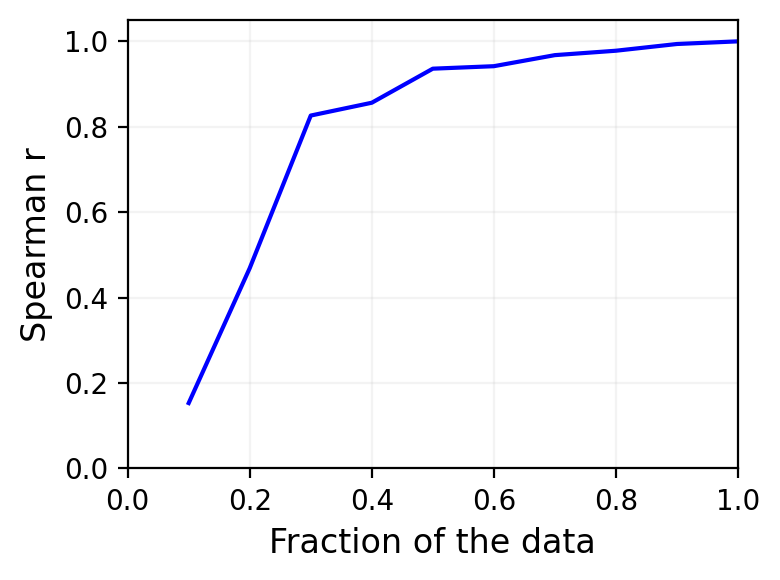

In [12]:
plt.figure(figsize = (4,3), dpi = 200)

plt.plot([1.00, 0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10], correlation, color = 'b')
plt.grid(True, alpha = 0.15)

plt.xlabel("Fraction of the data", size = 12)
plt.ylabel('Spearman r', size = 12)
plt.ylim([0, 1.05])
plt.xlim([0, 1])
plt.tight_layout()
plt.savefig('images/Model_consistency.pdf')
plt.show()